In [8]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_v=np.array([0,0,0])
cov_mat=np.array([[1,0,0],[0,1,0],[0,0,1]])

class1_sample=np.random.multivariate_normal(mu_v,cov_mat,20)
df=pd.DataFrame(class1_sample,columns=['f1','f2','f3'])
df['target']=1

In [9]:
mu_v1=np.array([0,0,0])
cov_mat1=np.array([[1,0,0],[0,1,0],[0,0,1]])

class2_sample=np.random.multivariate_normal(mu_v1,cov_mat1,20)
df1=pd.DataFrame(class2_sample,columns=['f1','f2','f3'])
df1['target']=0

In [12]:
df = pd.concat([df, df1], ignore_index=True)

In [14]:
df= df.sample(40)

In [15]:
df.head()

,f1,f2,f3,target
2,-0.367548,-1.137460,-1.322148,1
34,-0.822939,-1.598109,0.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


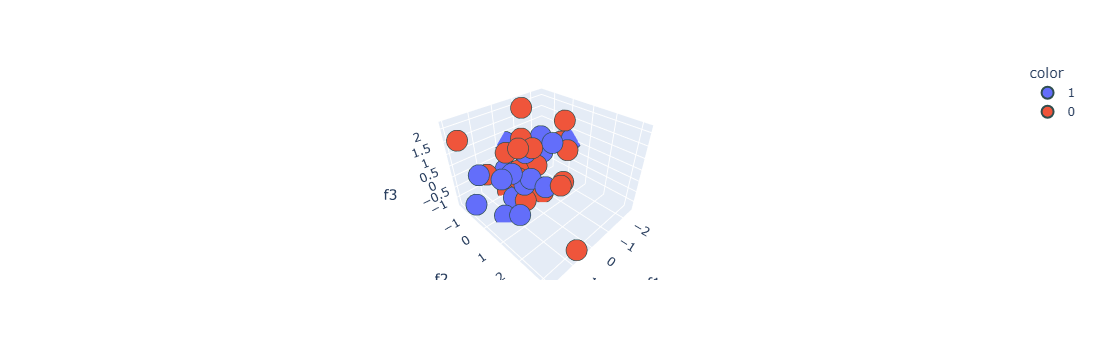

In [16]:
import plotly.express as px
fig=px.scatter_3d( df, x=df.f1, y=df.f2, z=df.f3, 
                   color=df.target.astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                 selector=dict(mode='markers'))

fig.show()

In [19]:
# 1 Apply Mean Centering
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

df.iloc[:,0:3] = sc.fit_transform(df.iloc[:,0:3])

In [22]:
# 2 Finding Covarience Matrix 
cov_matrix=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print(f"covarience Matrix : \n {cov_matrix}")

covarience Matrix : 
 [[ 1.02564103  0.06781177 -0.12497686]
 [ 0.06781177  1.02564103 -0.15241116]
 [-0.12497686 -0.15241116  1.02564103]]


In [23]:
# 3 Finding Eigen Value and eigen Vector
eig_val, eig_vec = np.linalg.eig(cov_matrix)

In [24]:
eig_val,eig_vec

(array([1.25911792, 0.95953081, 0.85827434]),
 array([[-0.51038783, -0.78846385,  0.34326234],
        [-0.569092  ,  0.60894401,  0.55255904],
        [ 0.64470037, -0.08667156,  0.75950607]]))

In [29]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D,proj3d
from matplotlib.patches import FancyArrowPatch

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


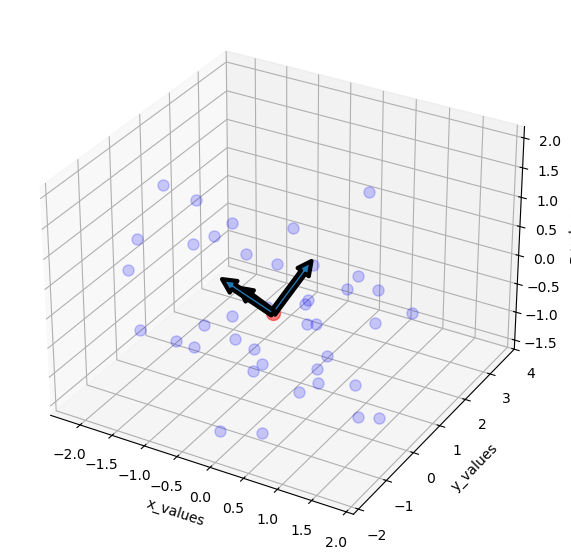

In [34]:
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        # Use super() for modern Python class initialization
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    # Replace the draw method with do_3d_projection
    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        # The proj_transform function returns 2D projected points
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        # Set the 2D positions for the FancyArrowPatch
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        # Return the minimum z-value for correct z-ordering
        return np.min(zs)

# Assuming 'df' and 'eig_vec' are defined earlier in your code
# (replace with your actual data if needed for a complete example)
# import pandas as pd
# df = pd.DataFrame({'f1': np.random.rand(10), 'f2': np.random.rand(10), 'f3': np.random.rand(10)})
# eig_vec = np.random.rand(3, 3)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(df['f1'], df['f2'], df['f3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['f1'].mean()], [df['f2'].mean()], [df['f3'].mean()], 'o', markersize=10, color='red', alpha=0.5)

for v in eig_vec.T:
    # Set shrinkA and shrinkB to 0 to ensure the arrow starts and ends exactly at the specified points
    a = Arrow3D([df['f1'].mean(), v[0]], [df['f2'].mean(), v[1]], [df['f3'].mean(), v[2]], mutation_scale=20, lw=3, shrinkA=0, shrinkB=0)
    ax.add_artist(a)
    
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.show()

In [35]:
pc=eig_vec[:2]

In [51]:
pc

array([[-0.51038783, -0.78846385,  0.34326234],
       [-0.569092  ,  0.60894401,  0.55255904]])

In [52]:
transformed_df=np.dot(df.iloc[:,0:3],pc.T)

In [53]:
new_df=pd.DataFrame(transformed_df,columns=['F1',"F2"])
new_df["target"]=df.target.values

In [54]:
new_df.head()

,F1,F2,target
0,0.560815,-1.471948,1
1,1.740278,-0.643400,0
2,-0.706342,-0.080489,1
3,-0.786474,-1.876564,1
4,1.105696,1.622028,1


<Axes: xlabel='F1', ylabel='F2'>

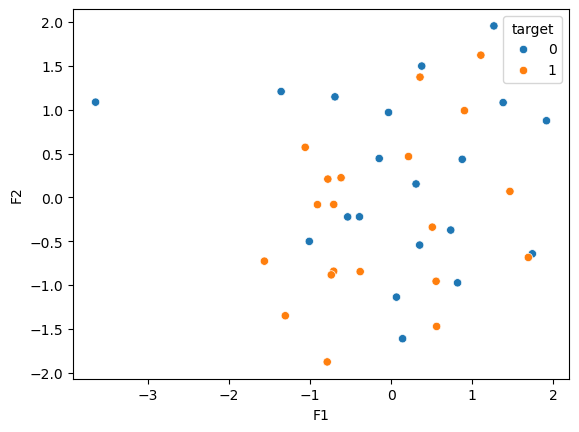

In [55]:
import seaborn as sns
sns.scatterplot(x=new_df.F1,y=new_df.F2,hue=new_df.target)